# EDA

In [1]:
# Environment Setup
import pandas as pd
import json
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np
from tqdm import tqdm
import os
import seaborn as sns

# Load leaf map
with open("../raw_data/PlantVillage-Dataset/leaf-map.json", "r") as f:
    leaf_map = json.load(f)
# Load image metadata
df_all = pd.read_csv("../data/metadata.csv")

### Handling Missing Leaf IDs and Fallback Cases
During metadata construction, we used the provided leaf-map.json to assign a leaf_id to each image. The leaf_id represents the physical leaf from which multiple images were taken and is essential for preventing data leakage when creating train/test splits.

However, we found that a subset of images could not be matched to any entry in the leaf mapping file and were assigned a fallback leaf ID. We manually inspected these fallback cases one by one by checking:
- The original image filename
- The generated image_identifier
- The corresponding entries in the leaf mapping CSV files
- The naming conventions across different disease categories

We found several issues:
- Some classes (e.g., Corn, Squash) do not have corresponding entries in the leaf mapping files.
- Some classes have inconsistent naming conventions between image filenames and the leaf mapping files (e.g., Tomato Late Blight, Septoria Leaf Spot).
- In some cases, only a subset of leaves were annotated in the mapping file, so certain images cannot be reliably assigned to a physical leaf.
- A few images appear to be mislabeled or have inconsistent leaf identifiers across files.

Because our project specifically requires leaf-level splitting to avoid data leakage (i.e., images from the same physical leaf appearing in both train and test sets), images without a reliable leaf_id cannot be safely used in the modeling pipeline.

Therefore, we decided to remove all images with fallback leaf IDs and only keep images with valid leaf_id entries for the rest of the analysis and model training.

This ensures that:
- Train/test splits are performed at the leaf level.
- No physical leaf appears in both training and test sets.
- Model evaluation better reflects real-world generalization rather than memorization of specific leaves.

In [2]:
# Fallback
fallback_count = df_all[df_all['leaf_id'].str.startswith('fallback_')].shape[0]
real_leaf_count = df_all[~df_all['leaf_id'].str.startswith('fallback_')].shape[0]

print(f"Real leaf_ids: {real_leaf_count}")
print(f"Fallback leaf_ids: {fallback_count}")
print(f"Total: {len(df_all)}")
print(f"\nFallback percentage: {fallback_count/len(df_all)*100:.1f}%")

# Remove iamges without leaf_id
df = df_all[~df_all["leaf_id"].str.startswith("fallback_")].copy()

print("Final dataset after removing fallback leaf_id:")
print("Images:", len(df))
print("Unique leaves:", df["leaf_id"].nunique())
print("Classes:", df["label"].nunique())
print("Crops:", df["crop"].nunique())

# Separate color and segmented images
# Use color version for the main analysis
df_color = df[df["data_type"] == "color"].copy()
df_seg = df[df["data_type"] == "segmented"].copy()

Real leaf_ids: 85031
Fallback leaf_ids: 23580
Total: 108611

Fallback percentage: 21.7%
Final dataset after removing fallback leaf_id:
Images: 85031
Unique leaves: 7944
Classes: 31
Crops: 12


## Dataset Summary

In [3]:
print("Total images:", len(df_color))
print("Unique leaf_id:", df_color["leaf_id"].nunique())
print("Unique classes:", df_color["label"].nunique())
print("Unique crops:", df_color["crop"].nunique())

print("\nImages per data_type:")
print(df_color["data_type"].value_counts())

print("\nHealthy vs Diseased:")
print(df_color["is_healthy"].value_counts())

print("\nTop 10 classes:")
print(df_color["label"].value_counts().head(10))

Total images: 42515
Unique leaf_id: 7944
Unique classes: 31
Unique crops: 12

Images per data_type:
data_type
color    42515
Name: count, dtype: int64

Healthy vs Diseased:
is_healthy
0    29610
1    12905
Name: count, dtype: int64

Top 10 classes:
label
Orange___Haunglongbing_(Citrus_greening)         5507
Soybean___healthy                                5090
Tomato___Tomato_Yellow_Leaf_Curl_Virus           2738
Peach___Bacterial_spot                           2297
Tomato___Bacterial_spot                          2127
Tomato___Spider_mites Two-spotted_spider_mite    1676
Apple___healthy                                  1645
Blueberry___healthy                              1502
Pepper,_bell___healthy                           1476
Tomato___Target_Spot                             1404
Name: count, dtype: int64


In [4]:
print("========== DATASET SUMMARY ==========")
print("Total images:", len(df_color))
print("Unique leaf_id:", df_color["leaf_id"].nunique())
print("Unique classes:", df_color["label"].nunique())
print("Unique crops:", df_color["crop"].nunique())

print("\n========== DATA TYPE ==========")
print(df_color["data_type"].value_counts())

print("\n========== HEALTHY VS DISEASE ==========")
print(df_color["is_healthy"].value_counts())

========== DATASET SUMMARY ==========
Total images: 42515
Unique leaf_id: 7944
Unique classes: 31
Unique crops: 12

========== DATA TYPE ==========
data_type
color    42515
Name: count, dtype: int64

========== HEALTHY VS DISEASE ==========
is_healthy
0    29610
1    12905
Name: count, dtype: int64


## Class Distribution

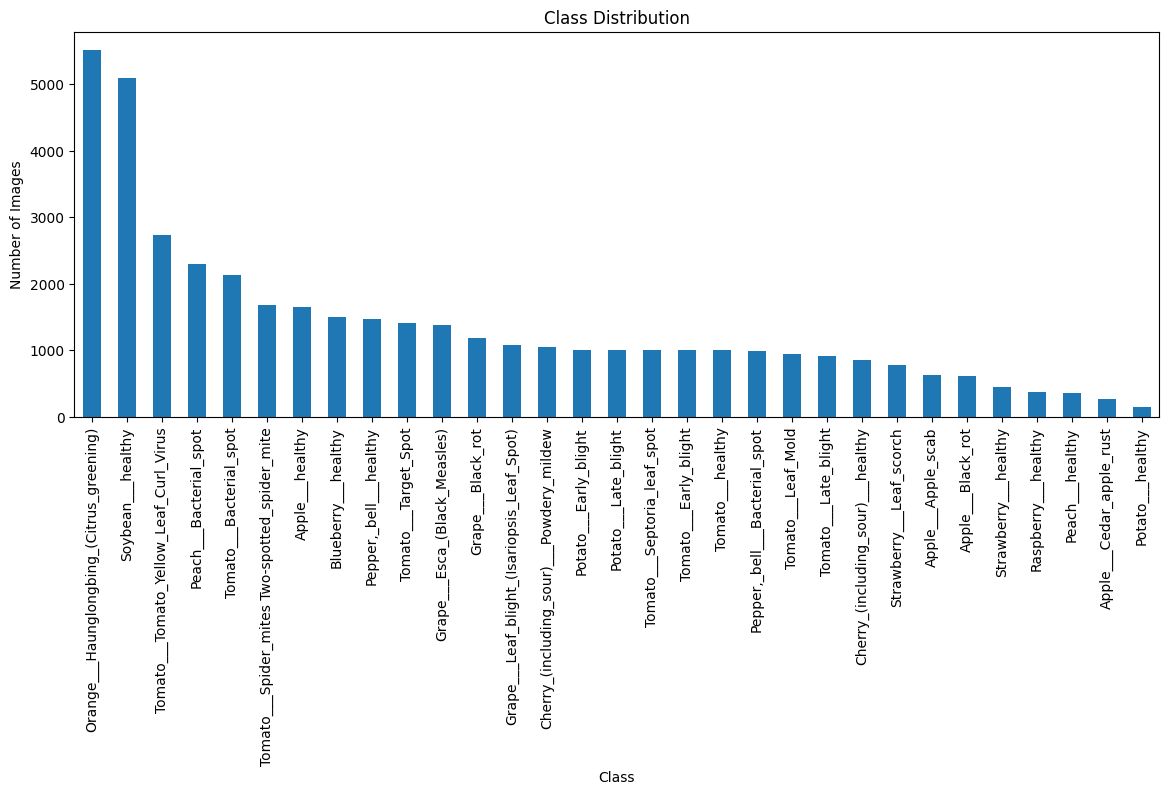

In [5]:
class_counts = df_color["label"].value_counts()

plt.figure(figsize=(14,5))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

- The dataset is class-imbalanced.
- Some classes (e.g., Orange Haunglongbing, Tomato Yellow Leaf Curl Virus) have significantly more images than others.
- Some classes have relatively small numbers of images, which may make them harder to classify and may lead to lower recall for those classes.
- Because of this imbalance, accuracy alone may not be sufficient, and we should also report F1-score per class.

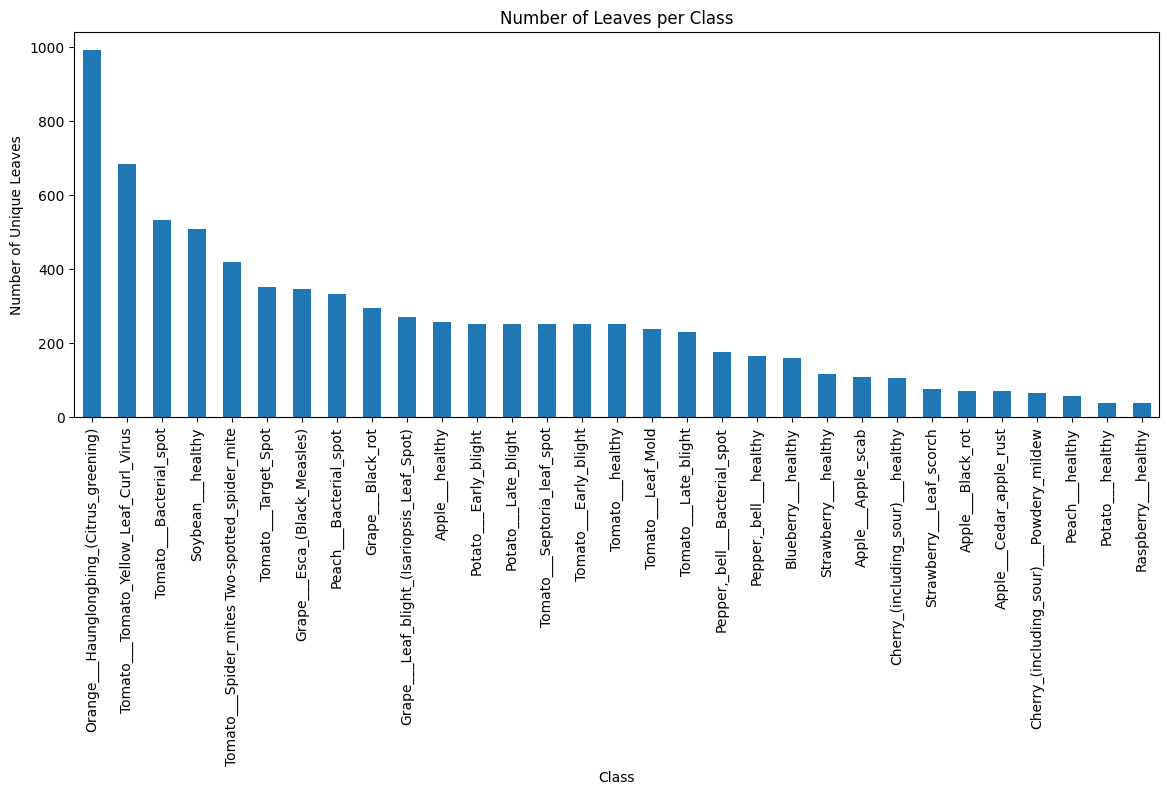

In [6]:
leaf_per_class = df_color.groupby("label")["leaf_id"].nunique().sort_values(ascending=False)

plt.figure(figsize=(14,5))
leaf_per_class.plot(kind="bar")
plt.title("Number of Leaves per Class")
plt.xlabel("Class")
plt.ylabel("Number of Unique Leaves")
plt.show()

count    7944.000000
mean        5.351838
std         3.000810
min         1.000000
25%         4.000000
50%         4.000000
75%         6.000000
max        33.000000
dtype: float64


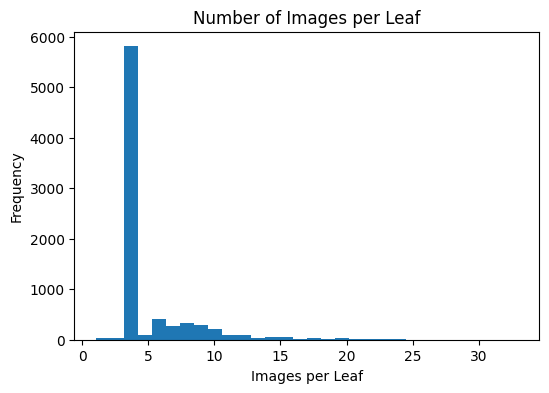

In [7]:
leaf_counts = df_color.groupby("leaf_id").size()

print(leaf_counts.describe())

plt.figure(figsize=(6,4))
plt.hist(leaf_counts, bins=30)
plt.title("Number of Images per Leaf")
plt.xlabel("Images per Leaf")
plt.ylabel("Frequency")
plt.show()

Most leaves have 2–5 images, meaning multiple images were taken from the same physical leaf. Therefore, splitting at the image level would lead to data leakage.

In [8]:
df_color["width"].unique() # only one value 256
df_color["height"].unique() # only one value 256


array([256])

Due to the large number of images, brightness statistics were computed on a random sample of images to approximate the distribution while reducing computation time.

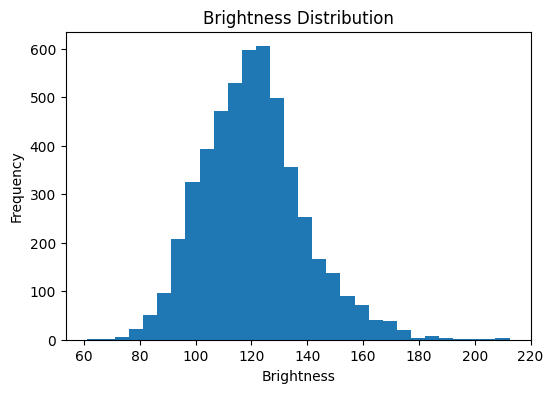

In [9]:
# brightness
def compute_brightness(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return np.mean(gray)

df_sample = df_color.sample(5000, random_state=42).copy()

brightness_list = []
base_dir = "../raw_data/PlantVillage-Dataset"

for path in tqdm(df_sample["image_path"], leave= False):
    full_path = os.path.join(base_dir, path)
    brightness_list.append(compute_brightness(full_path))

df_sample["brightness"] = brightness_list

plt.figure(figsize=(6,4))
plt.hist(df_sample["brightness"].dropna(), bins=30)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()

- The brightness distribution is approximately unimodal, but with a noticeable spread.
- This indicates that images were taken under different lighting conditions.
- Therefore, lighting variation is a realistic distribution shift scenario, and we will evaluate model robustness under brightness changes.

/var/folders/sc/8v6vkcjx3fdf4kn37p3rpq9m0000gn/T/ipykernel_93170/1447435765.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


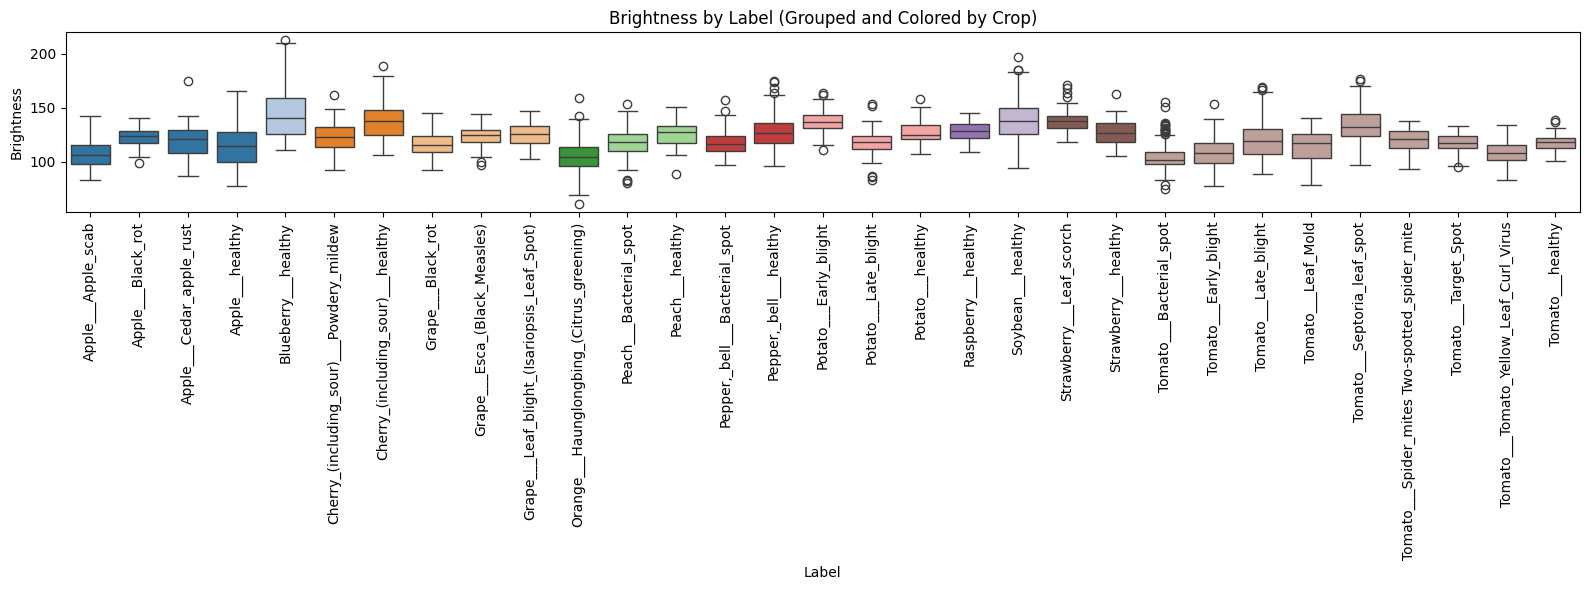

In [10]:

## Brightness by label and crop
# order by crop and label
label_order_df = (
    df_sample[["crop", "label"]]
    .drop_duplicates()
    .sort_values(["crop", "label"])
)

label_order = label_order_df["label"].tolist()

# add color to each type of crops
unique_crops = sorted(df_sample["crop"].unique())
crop_palette = dict(zip(unique_crops, sns.color_palette("tab20", n_colors=len(unique_crops))))

label_to_crop = (
    df_sample[["label", "crop"]]
    .drop_duplicates()
    .set_index("label")["crop"]
    .to_dict()
)

label_palette = {label: crop_palette[label_to_crop[label]] for label in label_order}

# plot
plt.figure(figsize=(16, 6))
ax = sns.boxplot(
    x="label",
    y="brightness",
    data=df_sample,
    order=label_order,
    palette=label_palette
)

plt.xticks(rotation=90)
plt.title("Brightness by Label (Grouped and Colored by Crop)")
plt.xlabel("Label")
plt.ylabel("Brightness")
plt.tight_layout()
plt.show()

- Brightness distributions vary across different crops and diseases.
- Some crops tend to have brighter images on average, while others are darker.
- In some cases, healthy and diseased leaves appear to have different brightness distributions, which may introduce dataset bias.
- This raises the concern that the model may rely on lighting conditions instead of disease patterns.

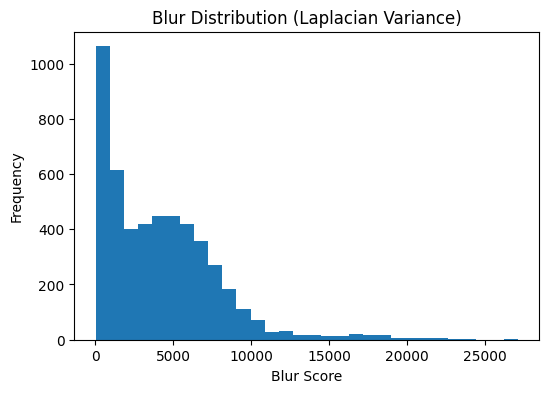

In [11]:
# Blur
def compute_blur(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

blur_list = []

for path in tqdm(df_sample["image_path"], leave= False):
    full_path = os.path.join(base_dir, path)
    blur_list.append(compute_blur(full_path))

df_sample["blur"] = blur_list

plt.figure(figsize=(6,4))
plt.hist(df_sample["blur"].dropna(), bins=30)
plt.title("Blur Distribution (Laplacian Variance)")
plt.xlabel("Blur Score")
plt.ylabel("Frequency")
plt.show()

- The blur distribution shows that some images are sharp while others are relatively blurry.
- This may be due to camera focus differences or motion blur during image capture.
- Therefore, blur is another realistic distribution shift scenario to test model robustness.

In [12]:
df_color = df[df["data_type"] == "color"].copy()
df_seg   = df[df["data_type"] == "segmented"].copy()

print("Color images:", len(df_color))
print("Segmented images:", len(df_seg))

print("Unique color image_identifier:", df_color["image_identifier"].nunique())
print("Unique segmented image_identifier:", df_seg["image_identifier"].nunique())

Color images: 42515
Segmented images: 42516
Unique color image_identifier: 40296
Unique segmented image_identifier: 40297


In [13]:
color_ids = set(df_color["image_identifier"])
seg_ids   = set(df_seg["image_identifier"])

print("Matched images:", len(color_ids & seg_ids))
print("Only in color:", len(color_ids - seg_ids))
print("Only in segmented:", len(seg_ids - color_ids))
# 找出那个多了一个的

Matched images: 40296
Only in color: 0
Only in segmented: 1


{'fam_b.msls 4430'}
raw/segmented/Grape___Esca_(Black_Measles)/7e1fd9b9-1fd9-4f98-93f5-8cf9ebc60dd9___FAM_B.Msls 4430_final_masked.jpg


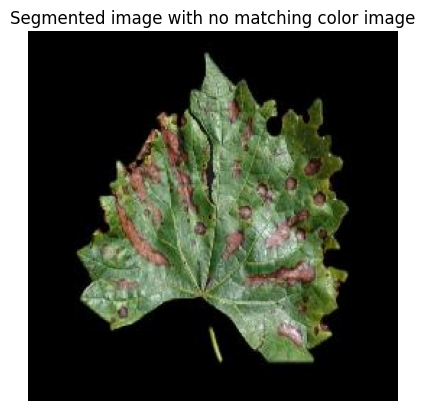

In [14]:
only_seg = seg_ids - color_ids
print(only_seg)
only_seg_id = list(only_seg)[0]
df_seg[df_seg["image_identifier"] == only_seg_id]

row = df_seg[df_seg["image_identifier"] == only_seg_id].iloc[0]
print(row["image_path"])

base_dir = "../raw_data/PlantVillage-Dataset"

img = cv2.imread(os.path.join(base_dir, row["image_path"]))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title("Segmented image with no matching color image")
plt.axis("off")
plt.show()

df_seg = df_seg[df_seg["image_identifier"] != only_seg_id]

There is one segmented image that does not have a corresponding color image. After inspection, this appears to be an extra processed image without a matching original image. Since this is only one image, it is removed from the segmented dataset to maintain one-to-one correspondence between color and segmented images.

In [15]:
df_sample_all = df.sample(5000, random_state=42).copy()

brightness_list = []
base_dir = "../raw_data/PlantVillage-Dataset"

for path in tqdm(df_sample_all["image_path"], leave= False):
    full_path = os.path.join(base_dir, path)
    brightness_list.append(compute_brightness(full_path))

df_sample_all["brightness"] = brightness_list

blur_list = []

for path in tqdm(df_sample_all["image_path"], leave= False):
    full_path = os.path.join(base_dir, path)
    blur_list.append(compute_blur(full_path))

df_sample_all["blur"] = blur_list

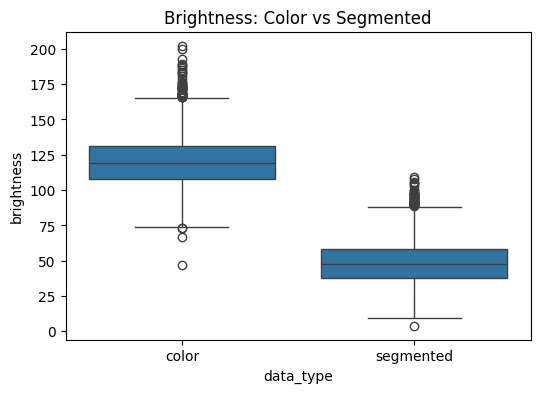

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x="data_type", y="brightness", data=df_sample_all)
plt.title("Brightness: Color vs Segmented")
plt.show()

Segmented images tend to have different brightness distributions because the background has been removed. This suggests that background contributes to overall brightness statistics in the original images.

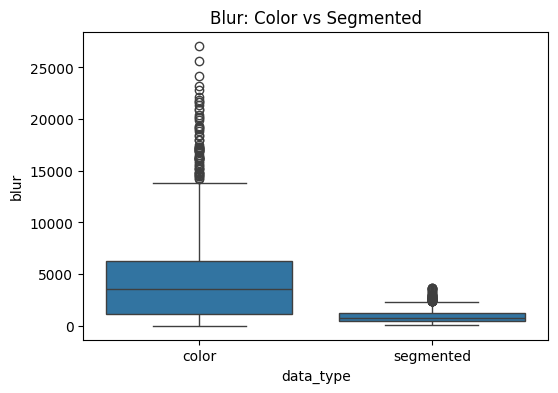

In [17]:
plt.figure(figsize=(6,4))
sns.boxplot(x="data_type", y="blur", data=df_sample_all)
plt.title("Blur: Color vs Segmented")
plt.show()

Segmented images have lower Laplacian variance because background textures are removed, reducing high-frequency components in the image.

100%|██████████| 5000/5000 [00:01<00:00, 2574.46it/s]


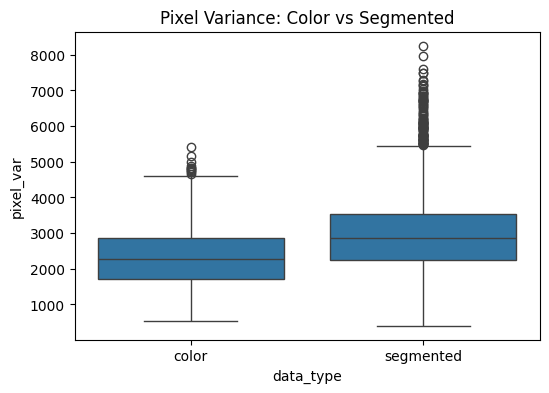

In [18]:
def compute_pixel_variance(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return np.nan
    return np.var(img)

df_sample_all["pixel_var"] = [
    compute_pixel_variance(os.path.join(base_dir, p))
    for p in tqdm(df_sample_all["image_path"])
]

plt.figure(figsize=(6,4))
sns.boxplot(x="data_type", y="pixel_var", data=df_sample_all)
plt.title("Pixel Variance: Color vs Segmented")
plt.show()

Pixel variance is higher in segmented images because the contrast between the dark background and the bright leaf increases the overall variance.